 In this notebook, I will apply the machine learning techniques  for image classification. 

## Imports

loading the libraries

In [33]:
import numpy as np
import gzip 

import matplotlib.pyplot as plt # In order to plot the images to see what we are dealing with
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 

In [34]:
def extract_data(filename, num_images, IMAGE_WIDTH):
    """Extract the images into a 4D tensor [image index, y, x, channels]."""
    with gzip.open(filename) as bytestream:
        bytestream.read(16)
        buf = bytestream.read(IMAGE_WIDTH * IMAGE_WIDTH * num_images)
        data = np.frombuffer(buf, dtype=np.uint8).astype(np.float32)
        data = data.reshape(num_images, IMAGE_WIDTH*IMAGE_WIDTH)
        return data

def extract_labels(filename, num_images):
    """Extract the labels into a vector of int64 label IDs."""
    with gzip.open(filename) as bytestream:
        bytestream.read(8)
        buf = bytestream.read(1 * num_images)
        labels = np.frombuffer(buf, dtype=np.uint8).astype(np.int64)
    return labels

In [35]:
### START FUNCTION
def get_data(num_train_images,num_test_images):
    IMAGE_WIDTH=28
    X_train = extract_data("image classification/train-images-idx3-ubyte.gz", num_train_images, IMAGE_WIDTH)
    y_train = extract_labels("image classification/train-labels-idx1-ubyte.gz", num_train_images)
    #Normalizing the data
    X_train /= 255.0
    
    X_test = extract_data("image classification/t10k-images-idx3-ubyte.gz", num_test_images, IMAGE_WIDTH)
    y_test = extract_labels("image classification/t10k-labels-idx1-ubyte.gz", num_test_images)
    #Normalizing the data
    X_test /= 255.0
    return (X_train, y_train), (X_test, y_test)

### END FUNCTION

In [63]:
y_test[50]

np.int64(6)

Label:  4


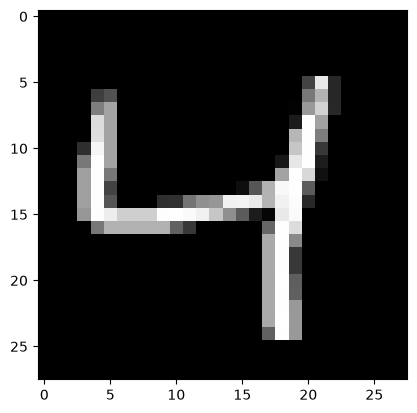

In [59]:
image_index = 2 ## Change me to view different images

print("Label: ", y_train[image_index])
reshaped_image = X_train[image_index].reshape((28, 28))

plt.imshow(reshaped_image, cmap='gray')
plt.show()

In [45]:
### START FUNCTION
def train_model(X_train, y_train):
    model = RandomForestClassifier(n_estimators=20, random_state=42)
    model.fit(X_train, y_train)
    return model

### END FUNCTION

In [46]:
clf = train_model(X_train, y_train)

In [50]:
### START FUNCTION
def calculate_accuracy(clf, X_test, y_test):
    y_pred = clf.predict(X_test)
    acurracy = accuracy_score(y_test, y_pred)
    return acurracy
### END FUNCTION

In [51]:
print(calculate_accuracy(clf,X_test,y_test))

0.891


In [54]:
### START FUNCTION
def get_class_report(clf, X_test, y_test):
    y_pred = clf.predict(X_test)
    class_report = classification_report(y_test, y_pred)
    return class_report

### END FUNCTION

In [55]:
print(get_class_report(clf,X_test,y_test))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97        85
           1       0.98      0.98      0.98       126
           2       0.88      0.90      0.89       116
           3       0.84      0.83      0.84       107
           4       0.86      0.90      0.88       110
           5       0.86      0.85      0.86        87
           6       0.91      0.93      0.92        87
           7       0.88      0.85      0.87        99
           8       0.93      0.78      0.85        89
           9       0.81      0.88      0.85        94

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



Predicted Label:  7


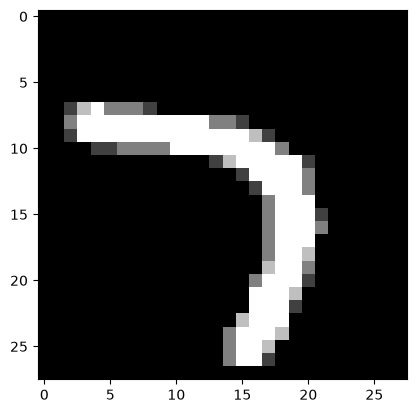

In [64]:
preds = clf.predict(X_test)

image_index = 60 ## Change me to see other predictions

print("Predicted Label: ",preds[image_index])
plt.imshow(X_test[image_index].reshape((28, 28)), cmap='gray')
plt.show()